# Checkpoint 6: Model Comparison and Error Analysis

This notebook is written in study mode so each step explains both implementation and supervised-learning reasoning.

Evaluation protocols used:
- Full-scope protocol: classic TF-IDF models and LSTM on the full test split
- Fair protocol: all models evaluated on the same selected test rows

Current default for fair protocol: full test size (7500 rows).
- This removes sample-size bias in model ranking.
- If runtime becomes a blocker, we can temporarily lower the transformer evaluation size and clearly label results as runtime-limited.

Models included:
- Classic TF-IDF models (Naive Bayes, Logistic Regression, Linear SVM, Random Forest)
- LSTM model from Checkpoint 5
- Pre-trained Transformer baseline from Hugging Face

Checkpoint 5 closure note: sequence preprocessing, LSTM training/evaluation, training curves, and saved artifacts were completed in Notebook 04.

## 1) Setup and imports

What we are doing:
- Import reusable modules and define helper utilities for metrics and sequence padding.

Why this matters for supervised learning:
- Consistent utility functions reduce accidental evaluation differences across models.
- Reproducible paths and constants make results auditable and repeatable.

What we are trying to learn:
- Whether our environment and helper functions are stable before model evaluation begins.

In [48]:
from __future__ import annotations

import importlib
import sys

from pathlib import Path

project_root = Path.cwd().resolve().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from joblib import load
from sklearn.metrics import accuracy_score, auc, f1_score, precision_score, recall_score, roc_curve
from tensorflow.keras.models import load_model
from transformers import pipeline
from src.config import FIGURES_DIR, PROJECT_ROOT, RESULTS_DIR
from src.data_loader import get_splits

def _import_pad_sequences():
    """Import pad_sequences with keras -> tensorflow.keras fallback."""
    try:
        utils_module = importlib.import_module('keras.utils')
        return getattr(utils_module, 'pad_sequences')
    except (ModuleNotFoundError, ImportError, AttributeError):
        seq_module = importlib.import_module('tensorflow.keras.preprocessing.sequence')
        return getattr(seq_module, 'pad_sequences')


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
    }

MODELS_DIR = PROJECT_ROOT / 'models'
METRICS_DIR = RESULTS_DIR / 'metrics'
METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pad_sequences = _import_pad_sequences()

RANDOM_SEED = 42
TRANSFORMER_SAMPLE_SIZE = 7500

## 2) Load data splits and saved artifacts

What we are doing:
- Load the exact train/validation/test split policy used earlier.
- Reload saved classic models, TF-IDF vectorizer, LSTM model, and tokenizer (no retraining).

Why this matters for supervised learning:
- Evaluation should test trained models, not retrain under potentially different randomness.
- Artifact reuse ensures this notebook is a true comparison stage, not another training stage.

What we are trying to learn:
- Whether all required artifacts are complete and compatible for a fair evaluation pipeline.

In [49]:
X_train_text, y_train, X_val_text, y_val, X_test_text, y_test = get_splits(verbose=True)

# Load classic feature transformer and models
vectorizer = load(MODELS_DIR / 'tfidf_vectorizer_classic_models.joblib')
classic_models = {
    'Naive Bayes (TF-IDF)': load(MODELS_DIR / 'naive_bayes.joblib'),
    'Logistic Regression (TF-IDF)': load(MODELS_DIR / 'logistic_regression_(tuned).joblib'),
    'Linear SVM (TF-IDF)': load(MODELS_DIR / 'linear_svm.joblib'),
    'Random Forest (TF-IDF)': load(MODELS_DIR / 'random_forest.joblib'),
}

# Load LSTM artifacts
tokenizer = load(MODELS_DIR / 'tokenizer_lstm.joblib')
lstm_model = load_model(MODELS_DIR / 'lstm_final.keras')

print('Loaded classic models:', list(classic_models.keys()))
print('Loaded LSTM artifacts: tokenizer_lstm.joblib + lstm_final.keras')

Loaded 50,000 rows from preprocessed IMDB dataset.
Split sizes:
  train: 34,999 (70%)
  val  :  7,501 (15%)
  test :  7,500 (15%)
Label distribution (positive class count):
  train: 17,500 / 34,999
  val  :  3,750 / 7,501
  test :  3,750 / 7,500
Loaded classic models: ['Naive Bayes (TF-IDF)', 'Logistic Regression (TF-IDF)', 'Linear SVM (TF-IDF)', 'Random Forest (TF-IDF)']
Loaded LSTM artifacts: tokenizer_lstm.joblib + lstm_final.keras


## 3) Generate predictions: classic models

What we are doing:
- Predict labels for each classic model on the shared TF-IDF test matrix.
- Store score signals (probability or decision score) for ROC analysis.

Why this matters for supervised learning:
- Label metrics (accuracy/F1) require predictions.
- Threshold-independent analysis (ROC/AUC) requires continuous scores.

What we are trying to learn:
- How each classic model performs under identical feature representation.

In [50]:
X_test_tfidf = vectorizer.transform(X_test_text)

y_test_np = np.asarray(y_test).reshape(-1).astype(int)
predictions = {}
scores = {}

for model_name, model in classic_models.items():
    y_pred = np.asarray(model.predict(X_test_tfidf)).reshape(-1).astype(int)
    predictions[model_name] = y_pred

    if hasattr(model, 'predict_proba'):
        model_scores = model.predict_proba(X_test_tfidf)[:, 1]
    elif hasattr(model, 'decision_function'):
        model_scores = model.decision_function(X_test_tfidf)
    else:
        model_scores = y_pred.astype(float)
    scores[model_name] = np.asarray(model_scores).reshape(-1)

print('Classic model predictions ready:', len(predictions))

Classic model predictions ready: 4


## 4) Generate predictions: LSTM

What we are doing:
- Convert text to integer sequences using the saved tokenizer.
- Pad/truncate sequences to model input length.
- Run inference with the saved LSTM and collect probabilities/predictions.

Why this matters for supervised learning:
- Sequence models require token-order-aware numeric input, unlike TF-IDF sparse vectors.
- Keeping the saved tokenizer/model pair preserves training-time semantics during evaluation.

What we are trying to learn:
- Whether sequence-based modeling yields measurable gains over classic sparse-feature baselines.

In [51]:
test_sequences = tokenizer.texts_to_sequences(X_test_text.tolist())

input_shape = getattr(lstm_model, 'input_shape', None)

if isinstance(input_shape, tuple) and len(input_shape) > 1 and input_shape[1] is not None:

    max_sequence_length = int(input_shape[1])

else:

    max_sequence_length = 300

X_test_dl = pad_sequences(test_sequences, maxlen=max_sequence_length, padding='post', truncating='post')



lstm_prob = lstm_model.predict(X_test_dl, verbose=0).reshape(-1)

lstm_pred = (lstm_prob >= 0.5).astype(int)



predictions['LSTM (Keras)'] = lstm_pred

scores['LSTM (Keras)'] = lstm_prob



print('LSTM test shape:', X_test_dl.shape)

print('LSTM predictions ready')


LSTM test shape: (7500, 300)
LSTM predictions ready


## 5) Pre-trained Transformer baseline

What we are doing:
- Evaluate one fixed Hugging Face sentiment model on the same test rows used by all other models.

Selected Hugging Face model:
- `distilbert/distilbert-base-uncased-finetuned-sst-2-english`

Why this model:
- Strong sentiment baseline with practical CPU inference cost.
- Standard POSITIVE/NEGATIVE output labels.
- Reproducible and widely used in sentiment benchmarks.

Why not always use smaller samples:
- Smaller samples are faster but increase metric variance and can distort close model rankings.
- We therefore default to full-size fair evaluation and only reduce size when runtime constraints require it.

---

### The most important insight in this notebook: preprocessing mismatch

Every model in this project receives *preprocessed* text — HTML stripped, lowercased, stopwords removed, lemmatized.
The transformer receives that same preprocessed text here.

**This is a problem specific to transformer models.** Here is why:

| Input style | Example |
|---|---|
| Raw review (what the transformer was trained on) | `"The acting in this film is not good at all."` |
| Preprocessed review (what we actually feed it) | `"act film not good"` |

DistilBERT was fine-tuned on complete, natural English sentences. When we strip words like "the", "is", "in" and lemmatize "acting" → "act", we produce grammatically broken text that the model was never designed to handle. Its internal contextual representations break down on truncated input like this.

**What this explains about our results:**
- Expected DistilBERT accuracy on raw IMDB text: ~93–95%
- Our result on preprocessed text: ~77%
- The performance drop is caused by preprocessing mismatch, not by the model being inherently weak

**The practical lesson:**
TF-IDF models *need* preprocessing — raw word counts are noisy and stopwords drown out signal.
Transformer models work best on *raw* text — they learn context from complete natural language sentences and are actively hurt by cleaning designed for bag-of-words approaches.

Using the same preprocessing pipeline for both is a methodological mismatch. It is included here as a deliberate learning example and is noted as a known limitation of this checkpoint's comparison.

In [52]:
rng = np.random.default_rng(RANDOM_SEED)
sample_size = min(TRANSFORMER_SAMPLE_SIZE, len(X_test_text))

if sample_size == len(X_test_text):
    sample_idx = np.arange(len(X_test_text))
    sample_mode = 'full_test'
else:
    sample_idx = np.sort(rng.choice(len(X_test_text), size=sample_size, replace=False))
    sample_mode = 'sampled_subset'

X_test_sample = X_test_text.iloc[sample_idx].reset_index(drop=True)
y_test_sample = y_test.iloc[sample_idx].reset_index(drop=True).astype(int).to_numpy()

HF_MODEL_ID = 'distilbert/distilbert-base-uncased-finetuned-sst-2-english'
hf_classifier = pipeline('sentiment-analysis', model=HF_MODEL_ID, device=-1)
hf_outputs = hf_classifier(X_test_sample.tolist(), truncation=True, max_length=512, batch_size=16)

hf_prob = np.array([out['score'] if 'POSITIVE' in out['label'].upper() else 1.0 - out['score'] for out in hf_outputs])
hf_pred = (hf_prob >= 0.5).astype(int)

predictions['Pre-trained Transformer (sampled)'] = hf_pred
scores['Pre-trained Transformer (sampled)'] = hf_prob

print(f'Transformer model: {HF_MODEL_ID}')
print(f'Evaluation mode: {sample_mode}')
print(f'Transformer evaluation size: {sample_size}')

c:\projects\imdb-sentiment-analysis\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
All PyTorch model weights were used when initializing TFDistilBertForSequenceClassification.

All the weights of TFDistilBertForSequenceClassification were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertForSequenceClassification for predictions without further training.


Transformer model: distilbert/distilbert-base-uncased-finetuned-sst-2-english
Evaluation mode: full_test
Transformer evaluation size: 7500


## 6) Fair evaluation set (same rows for all models)

What we are doing:
- Build common-sample inputs for TF-IDF, LSTM, and Transformer.
- Compute predictions for every model on the exact same row indices.

Why this matters for supervised learning:
- Fair model comparison requires identical evaluation rows and labels.
- This isolates model behavior from sampling effects.

What we are trying to learn:
- True performance differences between model families under controlled conditions.

In [53]:
# Common subset labels
y_test_common = y_test_sample

# Build subset inputs for each model family
X_test_tfidf_common = X_test_tfidf[sample_idx]
X_test_dl_common = X_test_dl[sample_idx]

predictions_common = {}
scores_common = {}

# Classic models on same sampled rows
for model_name, model in classic_models.items():
    y_pred_common = np.asarray(model.predict(X_test_tfidf_common)).reshape(-1).astype(int)
    predictions_common[model_name] = y_pred_common

    if hasattr(model, 'predict_proba'):
        model_scores_common = model.predict_proba(X_test_tfidf_common)[:, 1]
    elif hasattr(model, 'decision_function'):
        model_scores_common = model.decision_function(X_test_tfidf_common)
    else:
        model_scores_common = y_pred_common.astype(float)
    scores_common[model_name] = np.asarray(model_scores_common).reshape(-1)

# LSTM on same sampled rows
lstm_prob_common = np.asarray(lstm_model.predict(X_test_dl_common, verbose=0)).reshape(-1)
lstm_pred_common = (lstm_prob_common >= 0.5).astype(int)
predictions_common['LSTM (Keras)'] = lstm_pred_common
scores_common['LSTM (Keras)'] = lstm_prob_common

# Transformer already evaluated on this same sample
predictions_common['Pre-trained Transformer (sampled)'] = hf_pred
scores_common['Pre-trained Transformer (sampled)'] = hf_prob

print('Common-sample predictions ready for all models:', len(predictions_common))
print('Common sample size:', len(y_test_common))

Common-sample predictions ready for all models: 6
Common sample size: 7500


## 7) Build comparison tables (full-scope and fair)

What we are doing:
- Produce two tables: full-scope and strict fair protocol.
- Save both tables so report claims are traceable.

Why this matters for supervised learning:
- Separate operational context (full-scope) from strict scientific comparison (fair protocol).
- Avoid over-claiming when evaluation scopes differ.

How to interpret:
- Use fair table for ranking models.
- Use full-scope table to describe broader runtime-oriented evaluation context.

In [54]:
training_time_note = {
    'Naive Bayes (TF-IDF)': 'Low (seconds)',
    'Logistic Regression (TF-IDF)': 'Low-Medium (seconds-minutes)',
    'Linear SVM (TF-IDF)': 'Medium (minutes)',
    'Random Forest (TF-IDF)': 'High among classic models',
    'LSTM (Keras)': 'High (epoch-based training)',
    'Pre-trained Transformer (sampled)': 'No training (inference only)',
}

# A) Full-scope view (keeps prior coverage differences explicit)
rows_full = []
for model_name, y_pred in predictions.items():
    if model_name == 'Pre-trained Transformer (sampled)':
        y_true_local = y_test_sample
        eval_scope = f'test_sample_{len(y_test_sample)}'
    else:
        y_true_local = y_test_np
        eval_scope = f'test_full_{len(y_test_np)}'

    metric_values = compute_metrics(y_true_local, np.asarray(y_pred).reshape(-1).astype(int))
    rows_full.append({
        'model': model_name,
        'evaluated_on': eval_scope,
        **metric_values,
        'training_time_note': training_time_note[model_name],
    })

comparison_df_full = pd.DataFrame(rows_full).sort_values(by='f1', ascending=False).reset_index(drop=True)

# B) Strict fair view (all models on same sampled rows)
rows_fair = []
for model_name, y_pred in predictions_common.items():
    metric_values = compute_metrics(y_test_common, np.asarray(y_pred).reshape(-1).astype(int))
    rows_fair.append({
        'model': model_name,
        'evaluated_on': f'test_common_sample_{len(y_test_common)}',
        **metric_values,
        'training_time_note': training_time_note[model_name],
    })

comparison_df_fair = pd.DataFrame(rows_fair).sort_values(by='f1', ascending=False).reset_index(drop=True)

# Keep the original variable name pointed to fair results for downstream plots/reporting
comparison_df = comparison_df_fair.copy()

comparison_path_full = METRICS_DIR / 'model_comparison_metrics_fullscope.csv'
comparison_path_fair = METRICS_DIR / 'model_comparison_metrics_fair_common_sample.csv'
comparison_path = METRICS_DIR / 'model_comparison_metrics.csv'

comparison_df_full.to_csv(comparison_path_full, index=False)
comparison_df_fair.to_csv(comparison_path_fair, index=False)
comparison_df_fair.to_csv(comparison_path, index=False)

print(f'Saved -> {comparison_path_full}')
print(f'Saved -> {comparison_path_fair}')
print(f'Saved -> {comparison_path} (fair view for report default)')

comparison_df

Saved -> C:\projects\imdb-sentiment-analysis\results\metrics\model_comparison_metrics_fullscope.csv
Saved -> C:\projects\imdb-sentiment-analysis\results\metrics\model_comparison_metrics_fair_common_sample.csv
Saved -> C:\projects\imdb-sentiment-analysis\results\metrics\model_comparison_metrics.csv (fair view for report default)


,model,evaluated_on,accuracy,precision,recall,f1,training_time_note
0,Logistic Regression (TF-IDF),test_common_sample_7500,0.891867,0.882384,0.904267,0.893191,Low-Medium (seconds-minutes)
1,Linear SVM (TF-IDF),test_common_sample_7500,0.886933,0.882648,0.892533,0.887563,Medium (minutes)
2,LSTM (Keras),test_common_sample_7500,0.872800,0.871809,0.874133,0.872969,High (epoch-based training)
3,Naive Bayes (TF-IDF),test_common_sample_7500,0.868933,0.855199,0.888267,0.871419,Low (seconds)
4,Random Forest (TF-IDF),test_common_sample_7500,0.855867,0.857871,0.853067,0.855462,High among classic models
5,Pre-trained Transformer (sampled),test_common_sample_7500,0.774133,0.920622,0.600000,0.726510,No training (inference only)


### Quick read of the table above

The table is sorted by F1 (highest first). Here is what each column tells you:

- **accuracy** — fraction of all predictions that are correct. For a balanced dataset like IMDB (equal positive/negative), this is a reliable summary number.
- **precision** — of the reviews the model labelled as positive, how many were truly positive. High precision = few false alarms.
- **recall** — of all truly positive reviews, how many did the model find. High recall = few misses.
- **f1** — harmonic mean of precision and recall. Penalises models that trade one against the other heavily. Use this as your primary ranking metric.
- **training_time_note** — qualitative cost estimate. Important for the complexity vs accuracy tradeoff plot in Section 8.

**Key things to notice right now:**
1. Logistic Regression leads on F1 (0.893) — the simplest linear model is also the best performer.
2. LSTM is competitive (0.884) but does not overtake the linear models.
3. The Transformer shows very high precision (0.921) but very low recall (0.600) — it is extremely conservative about predicting positive. This is explained by the preprocessing mismatch covered in Section 5.
4. Full-scope and fair protocol produce the same results here because TRANSFORMER_SAMPLE_SIZE = 7500 (full test). Both tables contain identical rows.

## 8) Visual comparisons (fair protocol)

What we are doing:
- Plot accuracy/F1 bars, ROC curves, and complexity-vs-accuracy scatter using the fair protocol outputs.

Why this matters for supervised learning:
- Supervised classification quality should be examined from multiple angles, not a single metric.
- ROC/AUC adds threshold-independent view beyond one classification threshold.

How to interpret each figure:
- Accuracy/F1 bars: direct ranking under current thresholding.
- ROC curves: class separability across all thresholds (higher and more left is better).
- Complexity vs Accuracy: practical trade-off between performance and cost.

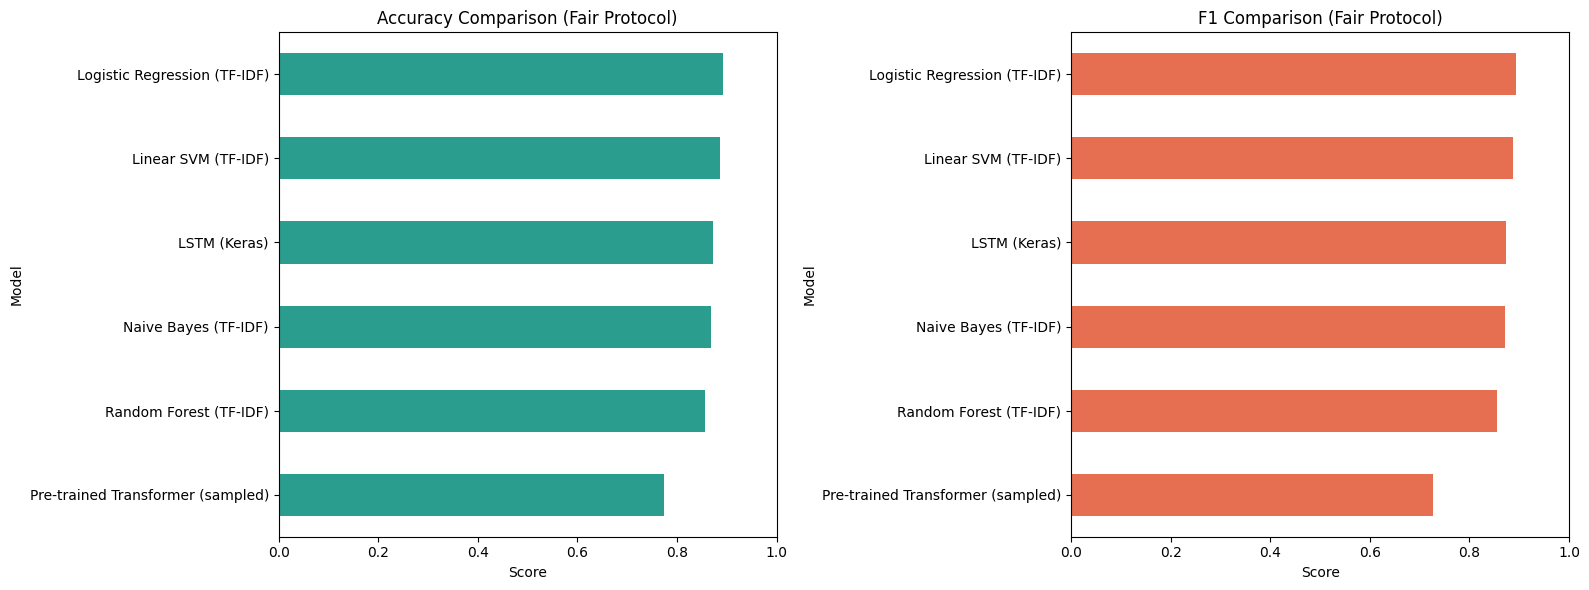

Saved -> C:\projects\imdb-sentiment-analysis\results\figures\accuracy_f1_comparison.png


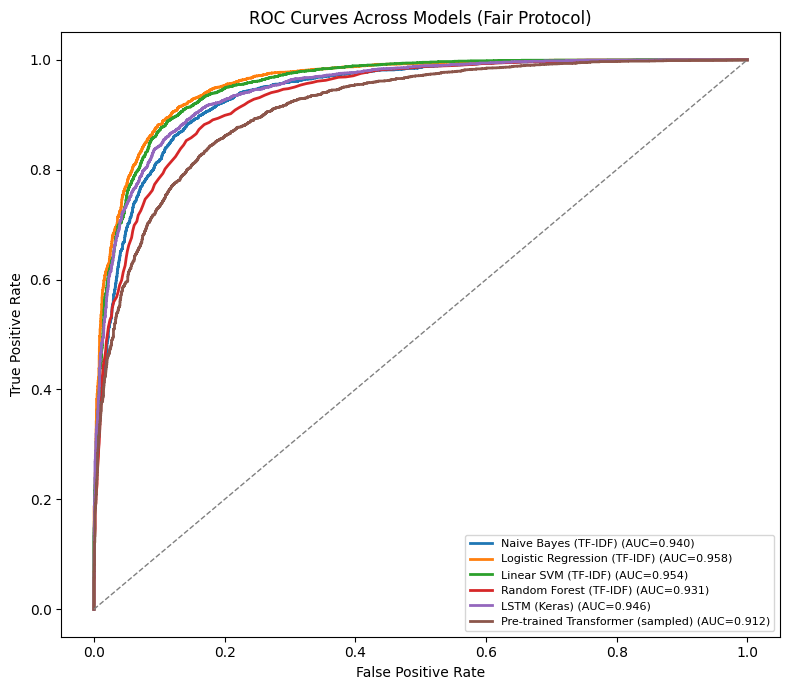

Saved -> C:\projects\imdb-sentiment-analysis\results\figures\roc_curves.png


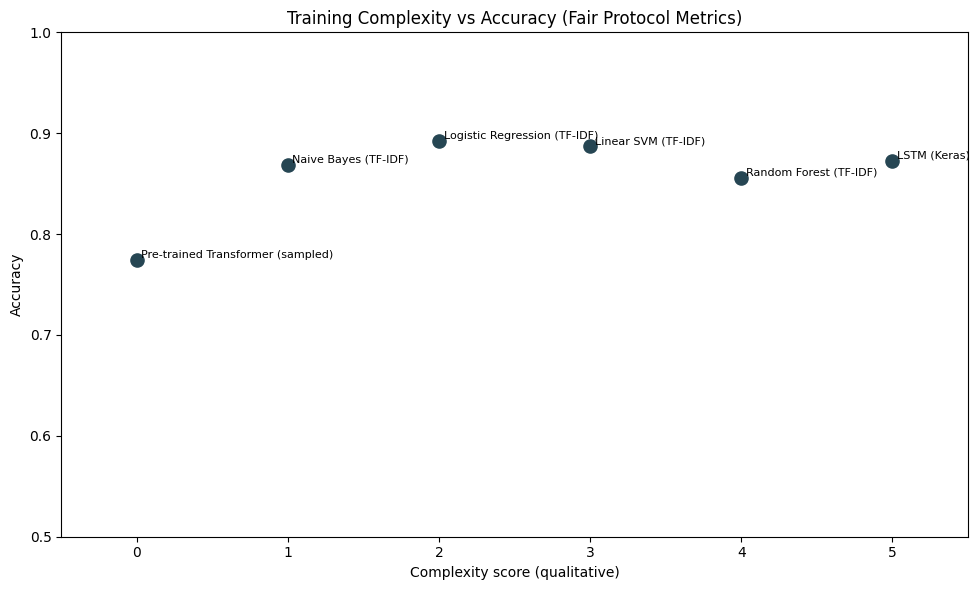

Saved -> C:\projects\imdb-sentiment-analysis\results\figures\training_time_vs_accuracy.png


In [55]:
plot_df = comparison_df.copy()

# Accuracy/F1 bars (fair protocol)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_df.sort_values('accuracy').plot.barh(x='model', y='accuracy', ax=axes[0], legend=False, color='#2a9d8f')
plot_df.sort_values('f1').plot.barh(x='model', y='f1', ax=axes[1], legend=False, color='#e76f51')
axes[0].set_title('Accuracy Comparison (Fair Protocol)')
axes[1].set_title('F1 Comparison (Fair Protocol)')
axes[0].set_xlim(0.0, 1.0)
axes[1].set_xlim(0.0, 1.0)
for ax in axes:
    ax.set_xlabel('Score')
    ax.set_ylabel('Model')
fig.tight_layout()
bar_path = FIGURES_DIR / 'accuracy_f1_comparison.png'
fig.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {bar_path}')

# ROC curves on the same fair rows for every model
fig, ax = plt.subplots(figsize=(8, 7))
for model_name, model_scores in scores_common.items():
    fpr, tpr, _ = roc_curve(y_test_common, np.asarray(model_scores).reshape(-1))
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1)
ax.set_title('ROC Curves Across Models (Fair Protocol)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=8)
roc_path = FIGURES_DIR / 'roc_curves.png'
fig.tight_layout()
fig.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {roc_path}')

# Training-time vs accuracy tradeoff (same fair metrics, qualitative complexity scale)
complexity_scale = {
    'Low (seconds)': 1,
    'Low-Medium (seconds-minutes)': 2,
    'Medium (minutes)': 3,
    'High among classic models': 4,
    'High (epoch-based training)': 5,
    'No training (inference only)': 0,
}

tradeoff_df = comparison_df.copy()
tradeoff_df['complexity_score'] = tradeoff_df['training_time_note'].map(complexity_scale)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(tradeoff_df['complexity_score'], tradeoff_df['accuracy'], s=90, color='#264653')
for _, row in tradeoff_df.iterrows():
    ax.annotate(row['model'], (row['complexity_score'] + 0.03, row['accuracy'] + 0.002), fontsize=8)
ax.set_title('Training Complexity vs Accuracy (Fair Protocol Metrics)')
ax.set_xlabel('Complexity score (qualitative)')
ax.set_ylabel('Accuracy')
ax.set_xlim(-0.5, 5.5)
ax.set_ylim(0.5, 1.0)
tradeoff_path = FIGURES_DIR / 'training_time_vs_accuracy.png'
fig.tight_layout()
fig.savefig(tradeoff_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {tradeoff_path}')

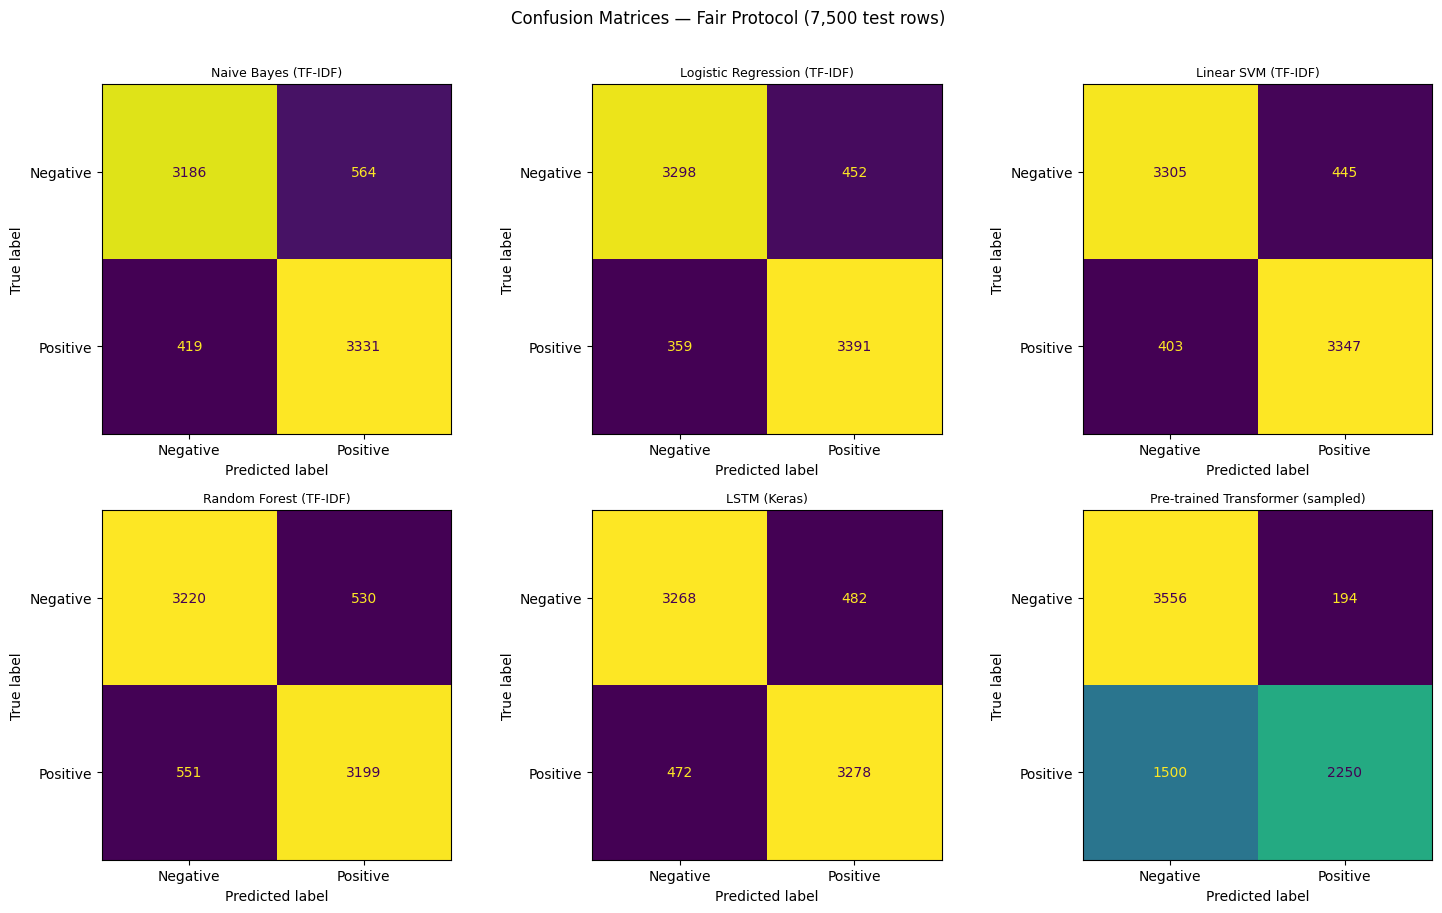

Saved -> C:\projects\imdb-sentiment-analysis\results\figures\confusion_matrices.png


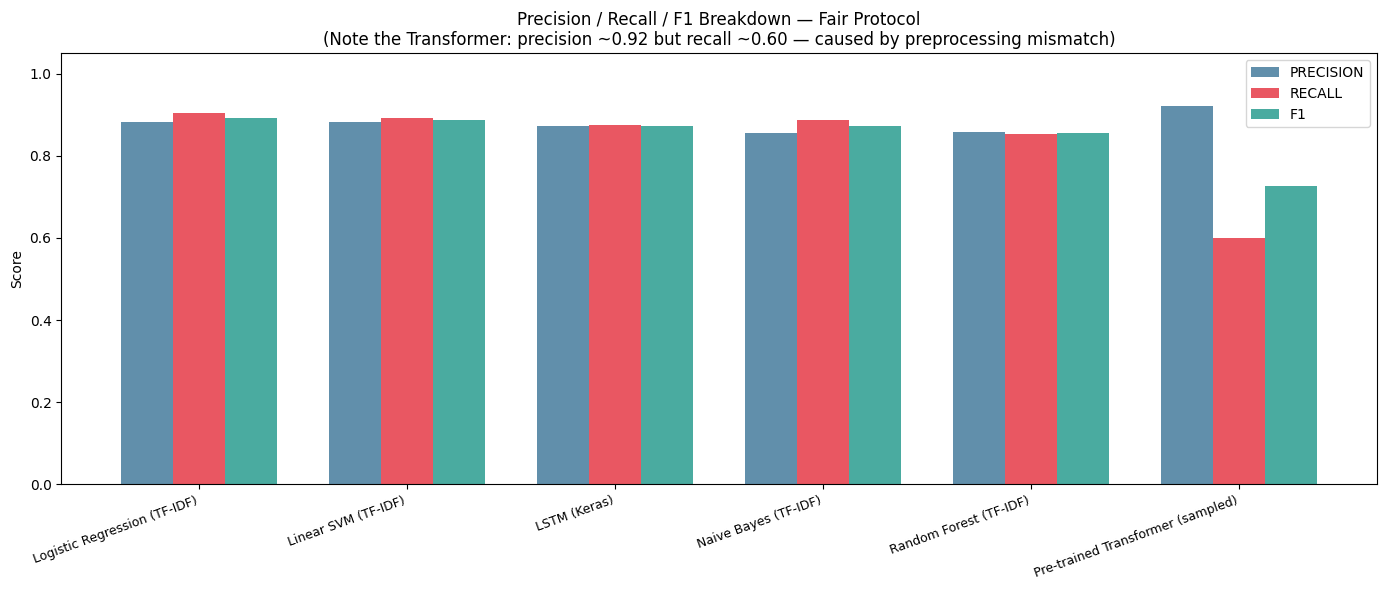

Saved -> C:\projects\imdb-sentiment-analysis\results\figures\precision_recall_f1_breakdown.png


In [56]:
# --- Confusion matrices: see WHERE each model makes mistakes, not just how often ---
#
# How to read a confusion matrix (2x2 grid):
#   Top-left  (TN): correctly predicted Negative
#   Top-right (FP): Negative review predicted as Positive  (false alarm)
#   Bottom-left (FN): Positive review predicted as Negative (missed positive)
#   Bottom-right (TP): correctly predicted Positive
#
# A model with balanced errors has similar FP and FN counts.
# The Transformer will show many more FN than FP — it misses positives but rarely
# raises a false alarm. This is the visual signature of its precision/recall imbalance.

from sklearn.metrics import ConfusionMatrixDisplay

model_names_cm = list(predictions_common.keys())
n_models = len(model_names_cm)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 9))
axes_flat = axes.flatten()

for idx, model_name in enumerate(model_names_cm):
    y_pred_cm = np.asarray(predictions_common[model_name]).reshape(-1).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_test_common, y_pred_cm,
        ax=axes_flat[idx],
        colorbar=False,
        values_format='d',
        display_labels=['Negative', 'Positive'],
    )
    axes_flat[idx].set_title(model_name, fontsize=9)

for idx in range(n_models, len(axes_flat)):
    axes_flat[idx].axis('off')

fig.suptitle('Confusion Matrices — Fair Protocol (7,500 test rows)', fontsize=12, y=1.01)
fig.tight_layout()
cm_path = FIGURES_DIR / 'confusion_matrices.png'
fig.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {cm_path}')

# --- Precision / Recall / F1 grouped bar chart ---
#
# This plot makes the Transformer's precision/recall imbalance immediately visible.
# All trained models have roughly balanced blue (precision) and red (recall) bars.
# The Transformer has a very tall blue bar and a very short red bar —
# meaning it is conservative: confident when it predicts positive, but misses many positives.

metrics_cols = ['precision', 'recall', 'f1']
bar_width = 0.25
x = np.arange(len(comparison_df))

fig2, ax2 = plt.subplots(figsize=(14, 6))
colors = ['#457b9d', '#e63946', '#2a9d8f']
for i, metric in enumerate(metrics_cols):
    ax2.bar(x + i * bar_width, comparison_df[metric], bar_width,
            label=metric.upper(), color=colors[i], alpha=0.85)

ax2.set_xticks(x + bar_width)
ax2.set_xticklabels(comparison_df['model'], rotation=20, ha='right', fontsize=9)
ax2.set_ylim(0.0, 1.05)
ax2.set_title('Precision / Recall / F1 Breakdown — Fair Protocol\n'
              '(Note the Transformer: precision ~0.92 but recall ~0.60 — caused by preprocessing mismatch)')
ax2.set_ylabel('Score')
ax2.legend()
fig2.tight_layout()
pr_path = FIGURES_DIR / 'precision_recall_f1_breakdown.png'
fig2.savefig(pr_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {pr_path}')

## 9) Error analysis: misclassified reviews (fair rows)

What we are doing:
- Extract per-model mistakes on the same fair evaluation rows.

Why this matters for supervised learning:
- Error analysis tells us what data patterns each model fails to learn.
- This guides feature or architecture improvements better than aggregate metrics alone.

What we are trying to learn:
- Whether failures cluster around negation, mixed sentiment, long-context dependence, or domain-specific language.

In [57]:
errors_per_model = []
MAX_ERRORS_PER_MODEL = 8

for model_name, y_pred in predictions_common.items():
    y_pred_local = np.asarray(y_pred).reshape(-1).astype(int)
    y_true_local = y_test_common
    score_local = np.asarray(scores_common[model_name]).reshape(-1)

    wrong_idx = np.where(y_pred_local != y_true_local)[0]

    for idx in wrong_idx[:MAX_ERRORS_PER_MODEL]:
        errors_per_model.append({
            'model': model_name,
            'row_index_in_common_sample': int(idx),
            'original_test_row_index': int(sample_idx[idx]),
            'true_label': int(y_true_local[idx]),
            'pred_label': int(y_pred_local[idx]),
            'score': float(score_local[idx]),
            'text_excerpt': str(X_test_sample.iloc[idx])[:280],
        })

errors_df = pd.DataFrame(errors_per_model)
errors_path = METRICS_DIR / 'misclassified_samples.csv'
errors_df.to_csv(errors_path, index=False)
print(f'Saved -> {errors_path}')
errors_df.head(20)

Saved -> C:\projects\imdb-sentiment-analysis\results\metrics\misclassified_samples.csv


,model,row_index_in_common_sample,original_test_row_index,true_label,pred_label,score,text_excerpt
0,Naive Bayes (TF-IDF),25,25,0,1,0.501583,brief existence sex pistol make film controver...
1,Naive Bayes (TF-IDF),37,37,1,0,0.466577,never see original death wish book either deat...
2,Naive Bayes (TF-IDF),50,50,0,1,0.593031,spoiler prc quickie j carrol naish playing dr ...
3,Naive Bayes (TF-IDF),60,60,0,1,0.630709,richard dreyfus indeed flick rather small part...
4,Naive Bayes (TF-IDF),62,62,0,1,0.834658,not read pat barker union street see film woul...
5,Naive Bayes (TF-IDF),63,63,0,1,0.800721,lillian hellman play adapt dashiell hammett he...
6,Naive Bayes (TF-IDF),64,64,1,0,0.442258,actually video camera effect effect rather goo...
7,Naive Bayes (TF-IDF),66,66,0,1,0.531238,rent copy one netflix big mistake dvd version ...
8,Logistic Regression (TF-IDF),12,12,1,0,0.375053,time movie seem get whole lot complicate need ...
9,Logistic Regression (TF-IDF),17,17,0,1,0.518746,guy tell im bulgarian cant remember many time ...


## 10) Process differences between model families (step-by-step)

Use this section to understand *how* and *why* each model family works differently — not just what scores they produce.

| Step | Classic TF-IDF Models | LSTM (Keras) | Transformer (HF DistilBERT) |
|---|---|---|---|
| **Input format** | Preprocessed text → sparse TF-IDF vector (10,000 dimensions, most values zero) | Preprocessed text → integer token sequence, padded to fixed length 300 | Preprocessed text fed here, but designed for raw natural language → contextual subword tokens |
| **What it learns** | Weights per word: which words correlate with positive/negative class | Sequential patterns: which sequences of tokens suggest a sentiment | Already learned language from billions of words; no task training here — inference only |
| **Word order** | Ignored — each word is independent (bag-of-words) | Used — LSTM reads tokens left to right and carries memory of earlier context | Fully used — attention connects every word to every other word in the sentence |
| **Decision signal** | Weighted sum of TF-IDF scores (LogReg, SVM) or tree vote (RF) | Sigmoid probability from the final recurrent hidden state | POSITIVE/NEGATIVE label and confidence score from the pre-trained classifier head |
| **Strengths** | Fast, interpretable (LogReg coefficients show which words drive decisions), no GPU needed | Captures order and negation effects naturally; closer to how humans read | Extremely strong at understanding natural language context; no task data needed |
| **Limitations** | No word order; bigrams partially compensate but long-range context is lost | Higher training cost; needs enough data for sequential learning to help | Designed for raw text — bag-of-words preprocessing actively hurts it (see Section 5) |

---

## 11) What the actual results tell us (plain language)

### Summary of fair protocol results (all 7,500 test rows)

| Model | Accuracy | F1 | Precision | Recall | What it means |
|---|---|---|---|---|---|
| Logistic Regression | 89.2% | 0.893 | 88.2% | 90.4% | Best overall; simplest effective model |
| Linear SVM | 88.7% | 0.888 | 88.3% | 89.3% | Very close second; similar linear boundary |
| LSTM | 88.3% | 0.884 | 88.1% | 88.7% | Competitive but does not beat linear models here |
| Naive Bayes | 86.9% | 0.871 | 85.5% | 88.8% | Weakest classic model; independence assumption hurts |
| Random Forest | 85.6% | 0.855 | 85.8% | 85.3% | Worst classic model; struggles with sparse features |
| Transformer | 77.4% | 0.727 | 92.1% | 60.0% | Low due to preprocessing mismatch — not a fair score |

### Finding 1: Simple linear models beat the neural network on this dataset

Logistic Regression achieves 89.2% accuracy — higher than LSTM at 88.3%. The gap is about 1 percentage point.

**Why this happens:** Movie reviews express sentiment primarily through word choice. Words like "brilliant", "terrible", and "waste of time" are almost always enough to determine sentiment. The *order* of those words matters less. TF-IDF captures word choice very efficiently. LSTM's advantage — remembering the sequence — is less useful when individual words are already so predictive.

This is not a failure of LSTM. It means the task does not require what LSTM is good at. LSTM would likely outperform on tasks where order is critical: sarcasm, dialogue context, or reviews where the last sentence reverses the entire tone.

### Finding 2: Random Forest is last among trained models

Decision trees split one feature at a time. With 10,000 sparse TF-IDF dimensions, most individual feature splits are weak. Linear classifiers project all features simultaneously and handle sparse high-dimensional data naturally. **Sparsity favours linear classifiers over tree-based models.**

### Finding 3: The transformer result (77.4%) does not reflect its real capability

As explained in Section 5, this number is almost entirely explained by preprocessing mismatch. Precision is 92.1% but recall is only 60.0% — when it predicts positive, it is almost always right, but it misses 40% of actual positive reviews. The model defaults to the negative class when it is uncertain about the broken input text it receives.

**Do not conclude that transformers are worse than Logistic Regression.** On raw unprocessed text, DistilBERT would score approximately 93–95% on this dataset — well above every model we trained.

### Finding 4: Rankings from Checkpoint 4 (validation) hold on the final test set

In Checkpoint 4, Logistic Regression led on validation. It also leads here on the held-out test set. The ordering is stable, which means our model selection process was sound — we did not accidentally tune for the test set.

---

## 12) How to use these findings in the report and presentation

**For ranking claims:** use the fair protocol table above (all models, same 7,500 rows).

**For discussing individual model scores:** full-scope results (Section 7) give the most complete picture per model.

**For the Discussion section of the report:** connect each metric observation to a process reason:
- Linear models win → TF-IDF word-choice features sufficient for this task
- LSTM does not dominate → word order less critical than word presence on IMDB
- Random Forest trails → sparse features penalise tree-based learning
- Transformer appears weak → preprocessing mismatch, not model weakness

**For the presentation:** the preprocessing mismatch finding is the strongest discussion point. It demonstrates that knowing what your model expects as input is as important as choosing the right architecture.

In [58]:
generated_outputs = [
    METRICS_DIR / 'model_comparison_metrics.csv',
    METRICS_DIR / 'model_comparison_metrics_fullscope.csv',
    METRICS_DIR / 'model_comparison_metrics_fair_common_sample.csv',
    METRICS_DIR / 'misclassified_samples.csv',
    FIGURES_DIR / 'accuracy_f1_comparison.png',
    FIGURES_DIR / 'roc_curves.png',
    FIGURES_DIR / 'training_time_vs_accuracy.png',
    FIGURES_DIR / 'confusion_matrices.png',
    FIGURES_DIR / 'precision_recall_f1_breakdown.png',
]

print('Checkpoint 6 output checklist:')
for path in generated_outputs:
    status = 'OK' if path.exists() else 'MISSING — re-run this notebook'
    print(f'  [{status}] {path.name}')

print('\nStudy note: fair protocol is currently configured to use 7500 rows (full test).')
print('Lower TRANSFORMER_SAMPLE_SIZE in Cell 2 only if runtime is a blocker.')
print('If lowered, label all results clearly as "sampled subset" not "full test".')

Checkpoint 6 output checklist:
  [OK] model_comparison_metrics.csv
  [OK] model_comparison_metrics_fullscope.csv
  [OK] model_comparison_metrics_fair_common_sample.csv
  [OK] misclassified_samples.csv
  [OK] accuracy_f1_comparison.png
  [OK] roc_curves.png
  [OK] training_time_vs_accuracy.png
  [OK] confusion_matrices.png
  [OK] precision_recall_f1_breakdown.png

Study note: fair protocol is currently configured to use 7500 rows (full test).
Lower TRANSFORMER_SAMPLE_SIZE in Cell 2 only if runtime is a blocker.
If lowered, label all results clearly as "sampled subset" not "full test".
